# Object Detection — Stage 1 (Localisation)

Trains `ObjectDetectorResNet` to predict up to `MAX_OBJECTS` bounding boxes per image.  
Each predicted slot is `[x, y, w, h, conf]`; confidence is a raw logit trained with BCE.

**Pipeline:**  
`get_detection_loaders` → `ObjectDetectorResNet` → `DetectionLoss` → `fit(task_type='detection')`

In [1]:
import sys
sys.path.insert(0, '..')

import torch

from utils.dataset   import get_detection_loaders
from utils.trainer   import fit, evaluate_detection_sweep, evaluate_detection
from utils.callbacks import ModelCheckpoint
from utils.losses    import DetectionLoss
from models import get_detector

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR    = '../data'
BATCH_SIZE  = 198
EPOCHS      = 60
MAX_OBJECTS = 24      # must match generator max_objects
CONF_THRESH = 0.7     # sigmoid threshold at inference
LAMBDA_CONF = 1.0     # weight on confidence loss

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.11.0+cu130


## 1 · Data Loaders

In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size = BATCH_SIZE,
    test=True,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
imgs, boxes, labels, mask = batch

print(f'Image batch shape : {imgs.shape}')
print(f'GT boxes shape    : {boxes.shape}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Image batch shape : torch.Size([198, 1, 224, 224])
GT boxes shape    : torch.Size([198, 16, 4])
Train batches: 1213 | Val batches: 76


## 2 · Model

In [3]:
model = get_detector(size="m", max_objects=MAX_OBJECTS).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    out = model(imgs.to(DEVICE))
print(f'Output shape: {out.shape}')  # (B, MAX_OBJECTS, 5)  — [x, y, w, h, conf]

Parameters: 8,836,856
Output shape: torch.Size([198, 24, 5])


## 3 · Loss — Huber + BCE confidence

`DetectionLoss` lives in `utils/losses.py`:
- Greedy IoU match → each GT box assigned to the best predicted slot
- **Box loss**: `HuberLoss` on matched pairs
- **Conf loss**: `BCEWithLogitsLoss` — matched slots → 1.0, background → 0.0

In [4]:
criterion = DetectionLoss(lambda_conf=LAMBDA_CONF, delta=1.0, use_pos_weight=True)
print('DetectionLoss ready.')

# ── Quick loss smoke-test ─────────────────────────────────────────────────────
boxes_v = boxes.to(DEVICE)
mask_v = mask.to(DEVICE)

with torch.no_grad():
    dummy_out   = model(imgs.to(DEVICE))
    loss_val    = criterion(dummy_out, boxes_v, mask_v)
print(f'Smoke-test loss: {loss_val.item():.4f}')  # should be finite

DetectionLoss ready.
Smoke-test loss: 58.6833


## 4 · Optimiser & Scheduler

In [5]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
)

NAME = "detector_m_new"
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f"../checkpoint/{NAME}_latest.pth",
    best_model_path=f"../checkpoint/{NAME}_best.pth",
    mode='max'   # maximise val_iou
)

scaler = torch.amp.GradScaler('cuda')

print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')

Optimizer : AdamW
Scheduler : OneCycleLR


## 5 · Train

In [6]:
history, logger = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    task_type   = 'detection',
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    verbose     = True,
    log         = True,
    model_label = NAME,
    resume=True
)

Training with bf16 autocast | Task: detection | Epochs: 60
[RunLogger] ▶  Run 'detector_m_new_20260721_153303' started — saving to 'C:\OD-From-Scratch\logs\ObjectDetectorResNet\detector_m_new_20260721_153303.json'
Could not resume training: No checkpoint found at '..\checkpoint\detector_m_new_latest.pth'. Cannot resume training.
Batch  1 | match=1.00 hungar=1.2ms data=720.1ms pad=0.9ms forward=163.4ms loss=7.2ms backward=237.5ms step=141.4ms
Batch  2 | match=1.00 hungar=1.3ms data=0.2ms pad=0.8ms forward=30.9ms loss=4.7ms backward=66.4ms step=2.3ms
Batch  3 | match=1.00 hungar=1.3ms data=0.2ms pad=0.7ms forward=30.9ms loss=5.3ms backward=65.7ms step=2.1ms
Batch  4 | match=1.00 hungar=1.2ms data=0.2ms pad=0.8ms forward=31.2ms loss=4.2ms backward=68.2ms step=2.1ms
Batch  5 | match=1.00 hungar=1.3ms data=0.1ms pad=0.7ms forward=31.3ms loss=4.4ms backward=65.5ms step=2.0ms
  --> Epoch Average Match Ratio: 1.0000
Train: 129.0s | Val: 47.4s
  --> PR: 0.096 | Rec: 0.102 | F1: 0.099 | TP: 1221

## 6 · Training Curves

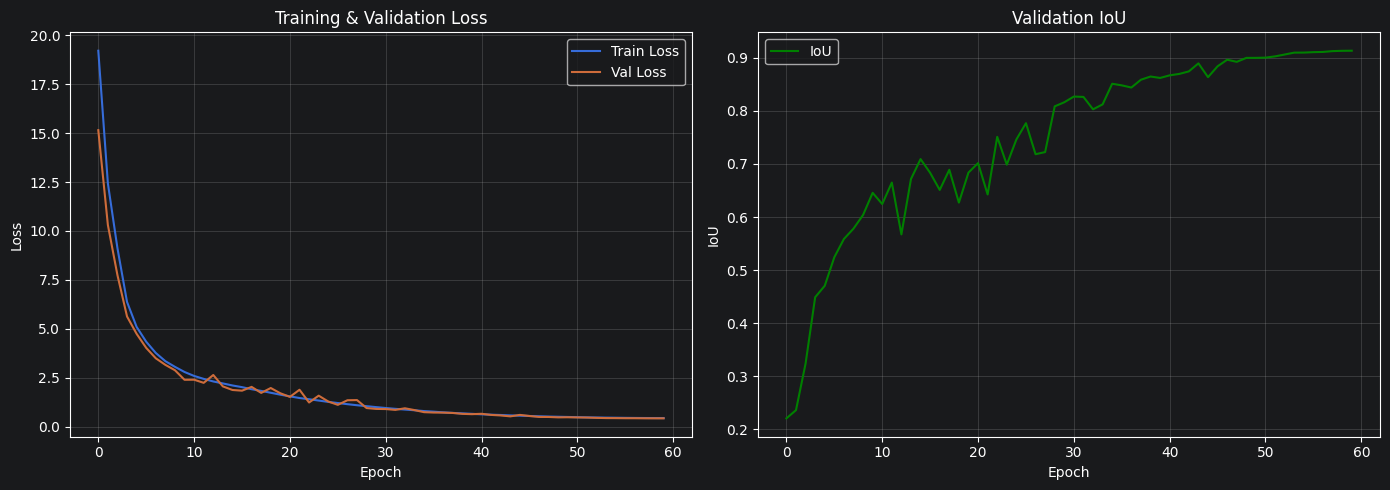

In [7]:
from utils.visualizer import Visualizer

Visualizer.visualize_training_curves(history['train_loss'], history['val_loss'], history['val_iou'], metric_label='IoU')

## 7 · Prediction Visualisation

- **Green** boxes = ground truth
- **Red** (dashed) boxes = model predictions with `conf > CONF_THRESH`

In [8]:
# -- Evaluate on Test Set (greedy IoU at conf=0.5) --
from utils.trainer import evaluate_detection
checkpoint.restore_best_weights()
metrics = evaluate_detection(model, test_loader, criterion, DEVICE)
print(f"Test loss : {metrics['val_loss']:.4f}")
print(f"Test IoU  : {metrics['val_iou']:.4f}")


Test loss : 0.4813
Test IoU  : 0.8997


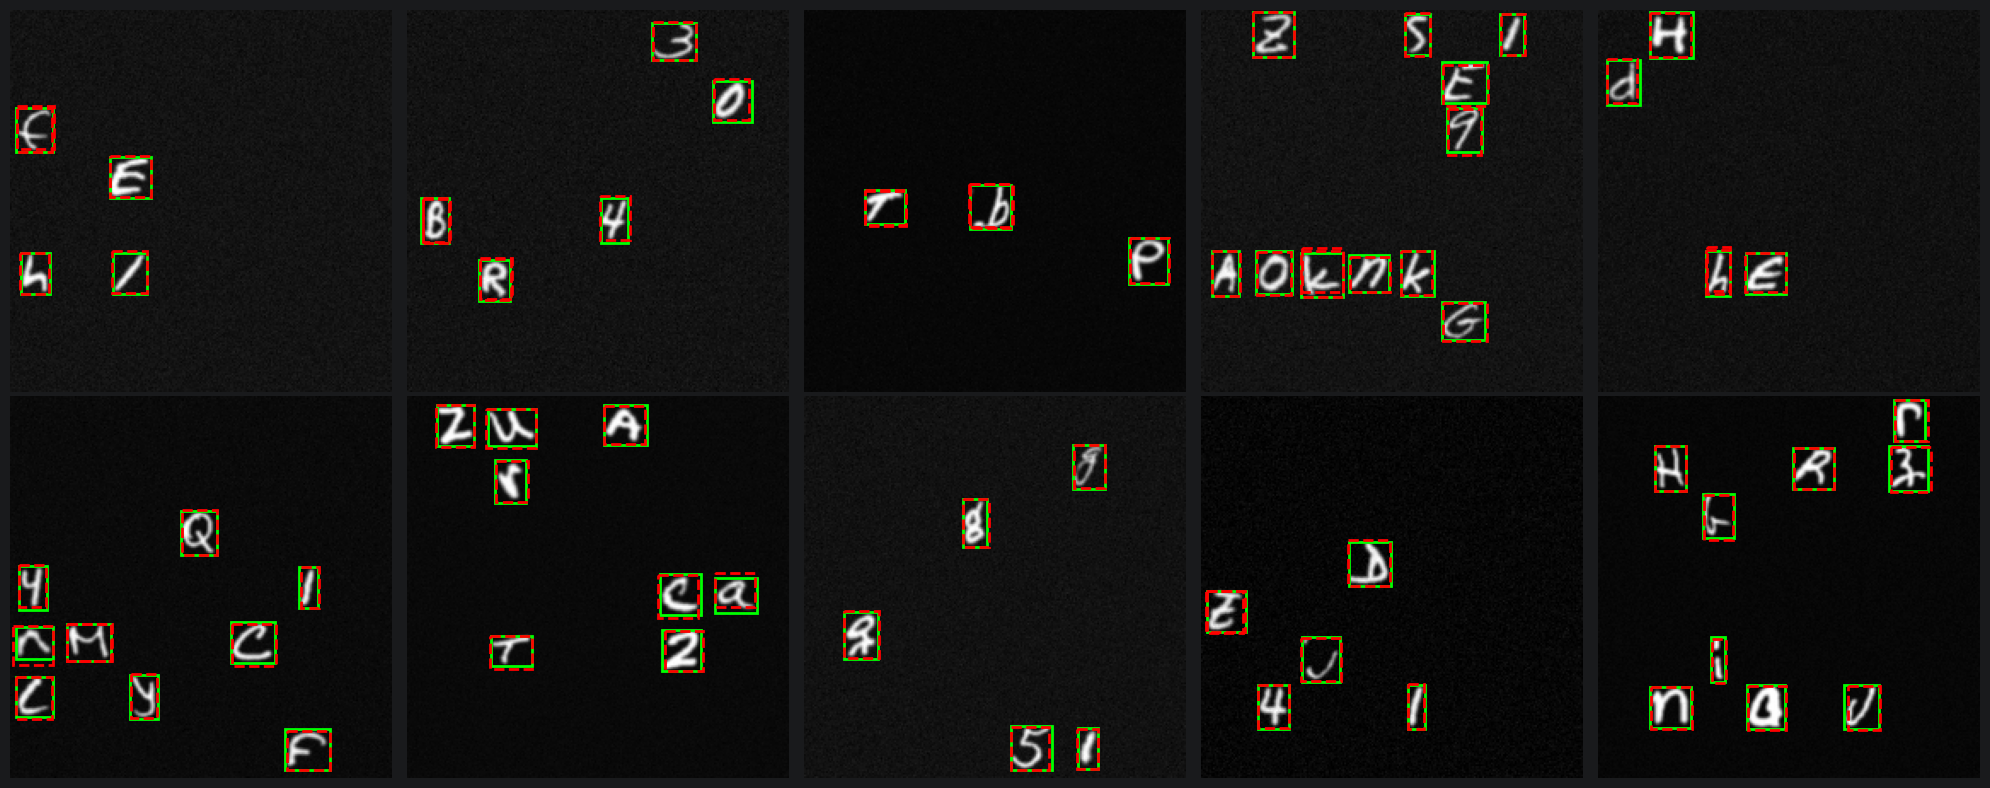

In [9]:
test_batch = next(iter(test_loader))
imgs_t, boxes_t, labels_t, mask_t = test_batch
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE)).cpu()
Visualizer.visualize_multi_detection_batch(
    imgs_v=imgs_t,
    preds=preds_t,
    boxes_v=boxes_t,
    mask_v=mask_t,
    conf_thresh=CONF_THRESH
)

## 8 · Test-Set Confidence Threshold Sweep

Run `evaluate_detection_sweep` on the held-out **test set** to see the full P/R/F1 trade-off
across confidence thresholds. The model runs **once** and all thresholds are swept in pure NumPy,
so the sweep is fast.

Results can be saved into the run JSON under `test_results.threshold_sweep` via
`logger.log_test_results()`.

In [10]:
sweep_results = evaluate_detection_sweep(
    model, test_loader, DEVICE,
    iou_threshold=0.5,
    print_table=True,
)

if logger is not None:
    logger.log_test_results(sweep_results, iou_threshold=0.5)



  Conf       P       R      F1       TP       FP       FN
--------------------------------------------------------
  0.20  0.8184  0.9862  0.8945   355597    78912     4970
  0.30  0.8433  0.9857  0.9089   355411    66060     5156
  0.40  0.8704  0.9847  0.9240   355043    52878     5524
  0.50  0.9018  0.9824  0.9404   354215    38568     6352
  0.60  0.9392  0.9759  0.9572   351886    22775     8681
  0.70  0.9728  0.9500  0.9613   342537     9564    18030
  0.80  0.9855  0.8884  0.9344   320316     4728    40251

[RunLogger] Test sweep (threshold_sweep) — IoU threshold: 0.5
  Conf       P       R      F1
--------------------------------
  0.20  0.8184  0.9862  0.8945
  0.30  0.8433  0.9857  0.9089
  0.40  0.8704  0.9847  0.9240
  0.50  0.9018  0.9824  0.9404
  0.60  0.9392  0.9759  0.9572
  0.70  0.9728  0.9500  0.9613
  0.80  0.9855  0.8884  0.9344
